
# Session 4 — **Box plots and Normal Distribution**
**Topic:** Percentiles, Quartiles, Five-number Summary, Boxplots, Z-scores, Normal Distribution  
**Goal:** Reproduces *all written exercises* with **complete Python solutions**.




## 1) Setup: Librairies

In [1]:

import numpy as np
import matplotlib.pyplot as plt



## 2) Exercise 1 — **Percentiles, Five-number summary, IQR, Outliers**

**Data (weights):** 25, 17, 32, 11, 40, 35, 13, 5, 46

**Tasks:**  
- Compute Q1 (25th), Median (50th), Q3 (75th), using np.percentile
- Build the **five-number summary**.  
- Compute **IQR**, fences, and flag outliers.
- Using matplotlib visual the boxplot using plt.boxplot


In [8]:
#Create an array
data = np.array([25, 17, 32, 11, 40, 35, 13, 5, 46])

# Compute the quartiles
q1 = np.percentile(data, 25)
q2 = np.percentile(data, 50)
q3 = np.percentile(data, 75)

min_value = np.min(data)
max_value = np.max(data)


five_num = np.array([min_value, q1, q2, q3, max_value])
IQR = q3 - q1
lower_fence = int(q1 - 1.5*IQR)
upper_fence = int(q3 + 1.5*IQR)
outliers = data[(data < lower_fence) | (data > upper_fence)]

#Answer
print("Q1, Q2, Q3:", q1, q2, q3)
print("Five-number summary (min, Q1, med, Q3, max):", five_num)
print("IQR:", IQR)
print("Fences (lower, upper):", [lower_fence, upper_fence])
print("Outliers:", outliers.tolist() if outliers.size else "None")


Q1, Q2, Q3: 13.0 25.0 35.0
Five-number summary (min, Q1, med, Q3, max): [ 5. 13. 25. 35. 46.]
IQR: 22.0
Fences (lower, upper): [-20, 68]
Outliers: None


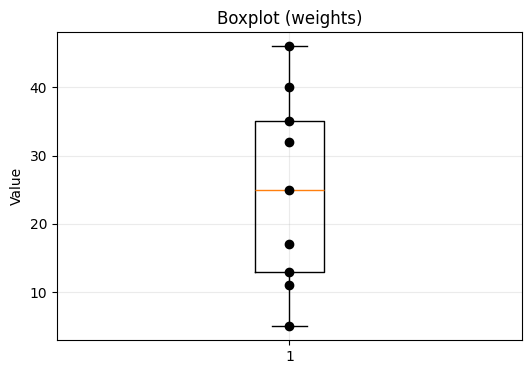

In [18]:

# Plot
plt.figure(figsize=(6,4))
plt.boxplot(data, vert=True, showfliers=True)
plt.title("Boxplot (weights)")
plt.scatter(np.ones(len(data)), data, color="black", zorder=3)

plt.ylabel("Value")
plt.grid(alpha=0.25)
plt.show()

Matplotlib does use the 1.5·IQR rule for whiskers. It only coincides with min/max when all values lie within that range (i.e., no outliers)

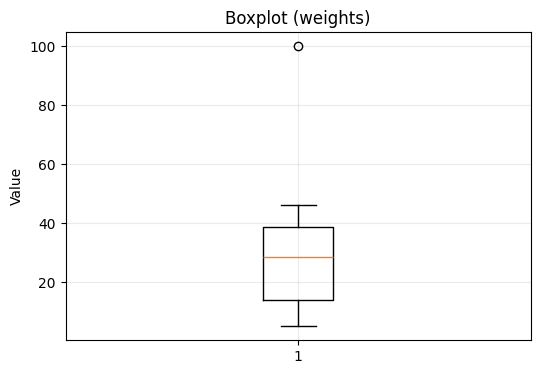

In [24]:
data_out = np.append(data, 100)
# Plot
plt.figure(figsize=(6,4))
plt.boxplot(data_out, vert=True, showfliers=True)
plt.title("Boxplot (weights)")
#plt.scatter(np.ones(len(data_out)), data_out, color="black", zorder=3)

plt.ylabel("Value")
plt.grid(alpha=0.25)
plt.show()


## 3) Exercise 2 — **Boxplot Reading & Comparison**

Two classes’ five-number summaries:

- **Class A:** min=42, Q1=58, median=66, Q3=74, max=92  
- **Class B:** min=48, Q1=60, median=65, Q3=85, max=98

**Questions:**  
- Which class is *more variable*? (Compare IQR and range.)  
- Any *skewness* indications?  
- Display both boxplot

In [31]:

A = [42, 58, 66, 74, 92]   # [min, Q1, median, Q3, max]
B = [48, 60, 65, 85, 98]


def range(data):
  return np.max(data) - np.min(data)

def iqr(data):
  return np.percentile(data,75) - np.percentile(data,25)

print("Class A — Range:", range(A), "IQR:", iqr(A))
print("Class B — Range:", range(B), "IQR:", iqr(B))

print("- B has larger IQR (25 vs 16) and range is equal (50). Middle spread is greater for B.")


# Skew hints: compare (median-Q1) vs (Q3-median)
def skewess(data):
    return (int(np.median(data)-(np.percentile(data,25))) , int(np.percentile(data,75)-np.median(data)))

print("Class A spreads (med-Q1, Q3-med):", skewess(A))
print("Class B spreads (med-Q1, Q3-med):", skewess(B))

print("- B shows right-skew: Q3-median is much larger than median-Q1.")


Class A — Range: 50 IQR: 16.0
Class B — Range: 50 IQR: 25.0
- B has larger IQR (25 vs 16) and range is equal (50). Middle spread is greater for B.
Class A spreads (med-Q1, Q3-med): (8, 8)
Class B spreads (med-Q1, Q3-med): (5, 20)
- B shows right-skew: Q3-median is much larger than median-Q1.


/tmp/ipython-input-3918860115.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=["Class A", "Class B"], vert=True)


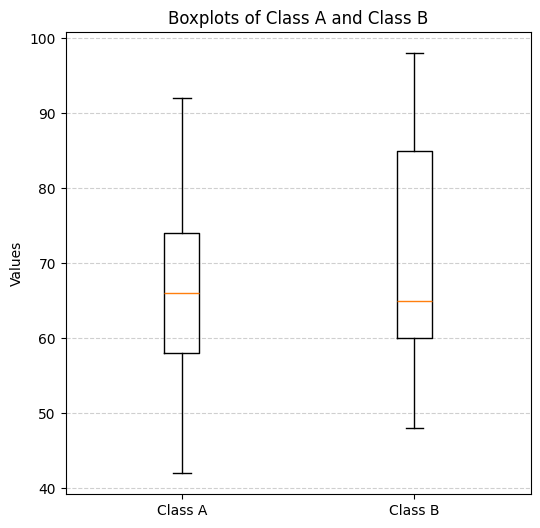

In [32]:
# Matplotlib wants data arrays, so we pass them as lists of [min, Q1, median, Q3, max]
data = [
    [A[0], A[1], A[2], A[3], A[4]],
    [B[0], B[1], B[2], B[3], B[4]]
]

# Draw boxplots
plt.figure(figsize=(6,6))
plt.boxplot(data, labels=["Class A", "Class B"], vert=True)

# Titles and labels
plt.title("Boxplots of Class A and Class B")
plt.ylabel("Values")

# Optional: grid lines for clarity
plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.show()


## 4) Exercise 3 — **Z-scores Across Populations**

- **Test A:** μ=70, σ=10. Alice scored 85.  
- **Test B:** μ=52, σ=6.  Ben scored 60.

1) Compute z-scores and decide who did better *relative to class*. Using the formula seen in class

2) What raw score on Test A corresponds to **z=2**?  
3) What z-score corresponds to **x=60** on Test A?


In [39]:

mu_A, sigma_A, score_A = 70, 10, 85
mu_B, sigma_B, score_B = 52, 6, 60

z_A = (score_A - mu_A)/sigma_A
z_B = (score_B - mu_B)/sigma_B


print(f"Alice: z = {z_A:.2f}")
print(f"Ben:   z = {z_B:.2f}")

if z_A>z_B:
    print("Alice did better relative to class.")
else:
    print("Ben did better relative to class.")

#
x_z2 = mu_A + 2*sigma_A
print("Raw score on Test A for z=2:", x_z2)


z_x60 = (60 - mu_A)/sigma_A
print("z-score for x=60 on Test A:", round(z_x60,2))


Alice: z = 1.50
Ben:   z = 1.33
Alice did better relative to class.
Raw score on Test A for z=2: 90
z-score for x=60 on Test A: -1.0



## 5) Exercise 4 — **Normal Probabilities**

Assume X ~ N(50, 3.2²):

- Using the empirical rule, give a rough % of values between 46.8 and 53.2

- Compute the z-score for x=41

- Using a z-table estimate the porcentage of values smaller or equal to 41. For this you have to use norm in scipy.

In SciPy, scipy.stats.norm is a distribution object.
There are 3 main things you can do with it:

- norm.pdf(x, loc, scale) → probability density at x
- norm.cdf(x, loc, scale) → cumulative probability P(X ≤ x)
- norm.rvs(loc, scale, size=n) → generate random variates, i.e. sample data from that normal distribution

Here you have to use norm.cdf.

The **Cumulative Distribution Function (CDF)** at a value \(x\) tells us the probability that a random variable \(X\) is less than or equal to \(x\):

\[
F(x) = P(X < x)
\]

**You will see this notion later in our lecture**

- Interpret your answer in words


In [45]:

mu, sigma = 50, 3.2
x_value = 41

print("Empirical rule ~68% between", mu-sigma, "and", mu+sigma)


z = (x_value - mu) / sigma
print("z-score for x=41:", round(z, 2))


from scipy.stats import norm

p = norm.cdf(x_value, loc=mu, scale=sigma)
print("P(X <= 41):", round(p*100, 2), "%")

print(f"Interpretation: About {round(p*100,2)}% of values are 41 or below, "
      "which means such a low score is very rare in this distribution.")

Empirical rule ~68% between 46.8 and 53.2
z-score for x=41: -2.81
P(X <= 41): 0.25 %
Interpretation: About 0.25% of values are 41 or below, which means such a low score is very rare in this distribution.



## 6) Exercise 5 — **From Percentile to Raw Score** *(Solved)*

Assume scores from a normal distribution N(100, 15²).  
- What raw score is the **84th percentile**?  

- What raw score is the **2.5th percentile**?

For this you need to derive the value of z and then apply z=(X-mu)/std


You can use norm.ppf where:

PPF: put in a probability p, get the value x that has that cumulative probability.
PPF stands for Percent Point Function

**You will see this notion later in our lecture**




In [46]:

mu, sigma = 100, 15
p1 = 0.84
p2 = 0.025



x_p84 = mu + norm.ppf(p1)*sigma
x_p25 = mu + norm.ppf(p2)*sigma

print(f"84th percentile raw score: {x_p84:.2f}")
print(f"2.5th percentile raw score: {x_p25:.2f}")


84th percentile raw score: 114.92
2.5th percentile raw score: 70.60



## 7) Exercice 6 **IQR (boxplot) vs Z-score outlier detection across different distributions**

 - Generate different datasets and add outliers

 - Compare outliers flagged by:

     (a) IQR fences (Q1 - 1.5*IQR, Q3 + 1.5*IQR)

     (b) |z| > 3 (z-scores via scipy.stats.zscore)

Data size: 42
Min/Max: 30 90
Added outliers: [30, 90]

IQR method
Q1, Median, Q3: 64.0 72.0 76.75
IQR: 12.75
Fences: 44.88 95.88
IQR outliers: [30]

z-score method
Mean: 70.26 SD: 9.39
|z|>3 outliers: [30]


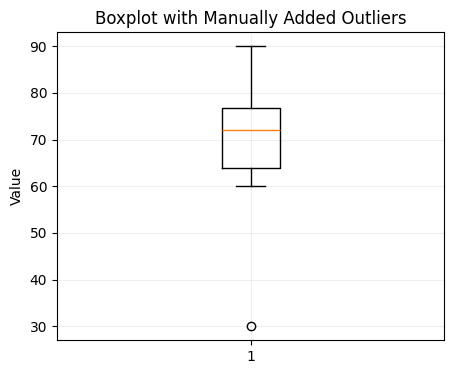

In [50]:
base = np.random.randint(60, 81, size=40)   # 40 values between 60 and 80

# Manually add a few outliers
outliers = np.array([30, 90])
x = np.concatenate([base, outliers])

print("Data size:", x.size)
print("Min/Max:", x.min(), x.max())
print("Added outliers:", outliers.tolist())

# -----------------------------
# 2) IQR outlier detection
# -----------------------------
Q1 = np.percentile(x, 25)
Q2 = np.percentile(x, 50)   # median
Q3 = np.percentile(x, 75)
IQR = Q3 - Q1
lower_fence = Q1 - 1.5 * IQR
upper_fence = Q3 + 1.5 * IQR

iqr_mask = (x < lower_fence) | (x > upper_fence)
iqr_outliers = x[iqr_mask]

print("\nIQR method")
print("Q1, Median, Q3:", round(Q1,2), round(Q2,2), round(Q3,2))
print("IQR:", round(IQR,2))
print("Fences:", round(lower_fence,2), round(upper_fence,2))
print("IQR outliers:", sorted(iqr_outliers.tolist()))

# -----------------------------
# 3) z-score outlier detection
# -----------------------------
mu = x.mean()
sd = x.std(ddof=0)  # population SD for simplicity
z = (x - mu) / sd
z_mask = np.abs(z) > 3      # threshold: |z| > 3
z_outliers = x[z_mask]

print("\nz-score method")
print("Mean:", round(mu,2), "SD:", round(sd,2))
print("|z|>3 outliers:", sorted(z_outliers.tolist()))

# -----------------------------
# 4) Quick boxplot to visualize
# -----------------------------
plt.figure(figsize=(5,4))
plt.boxplot(x, vert=True, showfliers=True)
plt.title("Boxplot with Manually Added Outliers")
plt.ylabel("Value")
plt.grid(alpha=0.2)
plt.show()